## Feature Engineering and Visualisations for NFL Plal by Play (2009 - 2018)

### Notebook Goal:

- This notebook builds the feature set that powers my NFL 4th down decision and win‑probability models. Starting from the cleaned play‑by‑play dataset (`fourth_down_scenarios_v2`)
- I create interpretable features that capture game context
- The objective is to transform raw play data into a structured, modeling‑ready table that downstream notebooks can use to compare go/punt/field goal decisions and estimate their impact on win probability.

In [1]:
# Load the necessary libraries and packages
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
import xgboost as xgb

import pandas as pd

import os

# Load the processed dataset for feature engineering and visualisations 

df2 = pd.read_csv('../../data/processed/fourth_down_scenarios_v2.csv')

df2.head(10)

,game_id,play_id,home_team,away_team,qtr,game_seconds_remaining,posteam_score,defteam_score,score_differential,posteam,...,interception,home_timeouts_remaining,away_timeouts_remaining,td_prob,fg_prob,ep,epa,play_type_clean,field_goal_result_clean,decision_4th_class
0,2009091000,139,PIT,TEN,1,3507.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.21,0.24,-0.70,2.10,punt,NaN,punt
1,2009091000,228,PIT,TEN,1,3394.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.14,0.02,-3.39,-0.02,punt,NaN,punt
2,2009091000,365,PIT,TEN,1,3205.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.15,0.50,0.76,-0.31,punt,NaN,punt
3,2009091000,522,PIT,TEN,1,3108.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.03,0.90,2.49,-3.63,field_goal,missed,field_goal
4,2009091000,603,PIT,TEN,1,3002.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.16,0.08,-2.60,1.53,punt,NaN,punt
5,2009091000,998,PIT,TEN,2,2593.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.15,0.44,0.56,0.20,punt,NaN,punt
6,2009091000,1279,PIT,TEN,2,2245.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.19,0.14,-0.57,-0.50,punt,NaN,punt
7,2009091000,1633,PIT,TEN,2,1942.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.01,0.95,2.82,-3.24,field_goal,blocked,field_goal
8,2009091000,2443,PIT,TEN,3,1512.0,7.0,7.0,0.0,PIT,...,0.0,3,3,0.31,0.30,0.96,0.10,punt,NaN,punt
9,2009091000,2563,PIT,TEN,3,1389.0,7.0,7.0,0.0,TEN,...,0.0,3,3,0.13,0.03,-3.42,0.69,punt,NaN,punt


In [2]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   game_id                  39336 non-null  int64  
 1   play_id                  39336 non-null  int64  
 2   home_team                39336 non-null  object 
 3   away_team                39336 non-null  object 
 4   qtr                      39336 non-null  int64  
 5   game_seconds_remaining   39333 non-null  float64
 6   posteam_score            39336 non-null  float64
 7   defteam_score            39336 non-null  float64
 8   score_differential       39336 non-null  float64
 9   posteam                  39336 non-null  object 
 10  defteam                  39336 non-null  object 
 11  fourth_down_converted    39336 non-null  float64
 12  fourth_down_failed       39336 non-null  float64
 13  drive                    39336 non-null  int64  
 14  side_of_field         

In [3]:
# normalize / format text columns for easy reading and modeling

df2['play_type_clean'] = (
    df2['play_type']
    .str.strip()
    .str.lower()
)

df2['field_goal_result_clean'] = (
    df2['field_goal_result']
    .str.strip()
    .str.lower()
)

In [4]:
# Build The 3 Class target variable for the 3 options taken when facing a 4th down play

# go_for it 
# field_goal
# punt
# create helper boolean columns for each 4th down decision type

is_punt = (
    (df2['punt_attempt'] == 1) |
    (df2['play_type_clean'] == 'punt')
)

is_field_goal = (
    (df2['field_goal_attempt'] == 1) |
    (df2['play_type_clean'] == 'field_goal') |
    (df2['field_goal_result_clean'].isin(['made', 'missed', 'blocked']))
)

is_go_for_it = (
    ~is_punt &
    ~is_field_goal &
    (
        df2['play_type_clean'].isin(['run', 'pass', 'qb_kneel', 'qb_spike', 'no_play']) |
        (df2['fourth_down_converted'] == 1) |
        (df2['fourth_down_failed'] == 1)
    )
)


In [5]:
# inspect the helper columns
print('Punt Percentage')
print(is_punt.value_counts(dropna=False, normalize=True) * 100)
print()
print('Field Goal Percentage')
print(is_field_goal.value_counts(dropna=False, normalize=True) * 100)
print()
print('Go For It Percentage')       
print(is_go_for_it.value_counts(dropna=False, normalize=True) * 100)    

Punt Percentage
True     60.796726
False    39.203274
Name: proportion, dtype: float64

Field Goal Percentage
False    77.193919
True     22.806081
Name: proportion, dtype: float64

Go For It Percentage
False    83.602807
True     16.397193
Name: proportion, dtype: float64


In [6]:
# create the 3-class target column

df2['decision_4th_class'] = np.select(
    [
        is_punt,
        is_field_goal,
        is_go_for_it
    ],
    [
        'punt',
        'field_goal',
        'go_for_it'
    ],
    default= None
)

In [7]:
# validate that each row maps to one and only one decision class

decision_flag_count = (
    is_punt.astype(int) +
    is_field_goal.astype(int) +
    is_go_for_it.astype(int)
)

print(decision_flag_count.value_counts(dropna=False))



1    39336
Name: count, dtype: int64


In [8]:
# inspect the new target column

df2['decision_4th_class'].value_counts(dropna=False, normalize= True) * 100



decision_4th_class
punt          60.796726
field_goal    22.806081
go_for_it     16.397193
Name: proportion, dtype: float64

In [9]:
# drop rows with missing target labels and keep only valid 3-class outcomes

fourth_down_scenarios_v2 = df2.dropna(
    subset=['decision_4th_class']
).copy()

In [10]:
# Encode For Modeling
# Encode the 3 unique decision classes as integers

decision_map = {
    'punt': 0,
    'field_goal': 1,
    'go_for_it': 2
}



In [11]:
fourth_down_scenarios_v2.head(10)

,game_id,play_id,home_team,away_team,qtr,game_seconds_remaining,posteam_score,defteam_score,score_differential,posteam,...,interception,home_timeouts_remaining,away_timeouts_remaining,td_prob,fg_prob,ep,epa,play_type_clean,field_goal_result_clean,decision_4th_class
0,2009091000,139,PIT,TEN,1,3507.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.21,0.24,-0.70,2.10,punt,NaN,punt
1,2009091000,228,PIT,TEN,1,3394.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.14,0.02,-3.39,-0.02,punt,NaN,punt
2,2009091000,365,PIT,TEN,1,3205.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.15,0.50,0.76,-0.31,punt,NaN,punt
3,2009091000,522,PIT,TEN,1,3108.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.03,0.90,2.49,-3.63,field_goal,missed,field_goal
4,2009091000,603,PIT,TEN,1,3002.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.16,0.08,-2.60,1.53,punt,NaN,punt
5,2009091000,998,PIT,TEN,2,2593.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.15,0.44,0.56,0.20,punt,NaN,punt
6,2009091000,1279,PIT,TEN,2,2245.0,0.0,0.0,0.0,PIT,...,0.0,3,3,0.19,0.14,-0.57,-0.50,punt,NaN,punt
7,2009091000,1633,PIT,TEN,2,1942.0,0.0,0.0,0.0,TEN,...,0.0,3,3,0.01,0.95,2.82,-3.24,field_goal,blocked,field_goal
8,2009091000,2443,PIT,TEN,3,1512.0,7.0,7.0,0.0,PIT,...,0.0,3,3,0.31,0.30,0.96,0.10,punt,NaN,punt
9,2009091000,2563,PIT,TEN,3,1389.0,7.0,7.0,0.0,TEN,...,0.0,3,3,0.13,0.03,-3.42,0.69,punt,NaN,punt


In [12]:
# Outcome columns for later analysis only

fourth_down_scenarios_v2["fourth_down_success"] = np.where(
    (fourth_down_scenarios_v2["fourth_down_converted"].fillna(0) == 1) |
    (fourth_down_scenarios_v2["touchdown"].fillna(0) == 1) |
    (fourth_down_scenarios_v2["field_goal_result_clean"].fillna("").str.lower() == "made"),
    1, 0
)

In [13]:
# derive eventual game winner

fourth_down_scenarios_v3 = fourth_down_scenarios_v2.sort_values(["game_id", "play_id"]).copy()

final_scores = (
    fourth_down_scenarios_v3.groupby("game_id")
      .tail(1)[["game_id", "home_team", "away_team", "posteam_score", "defteam_score", "posteam", "defteam"]]
      .copy()
)

# reconstruct home/away final scores from the final row
def infer_final_scores(row):
    if row["posteam"] == row["home_team"]:
        home_score = row["posteam_score"]
        away_score = row["defteam_score"]
    else:
        home_score = row["defteam_score"]
        away_score = row["posteam_score"]
    return pd.Series({"home_final": home_score, "away_final": away_score})

final_scores[["home_final", "away_final"]] = final_scores.apply(infer_final_scores, axis=1)

# Determine the winner 

final_scores["winner"] = np.select(
    [
        final_scores["home_final"] > final_scores["away_final"],
        final_scores["away_final"] > final_scores["home_final"]
    ],
    [
        final_scores["home_team"],
        final_scores["away_team"]
    ],
    default="TIE"
)

fourth_down_scenarios_v3 = fourth_down_scenarios_v3.merge(
    final_scores[["game_id", "winner"]],
    on="game_id",
    how="left"
)

fourth_down_scenarios_v3["pos_team_win"] = np.where(
    fourth_down_scenarios_v3["posteam"] == fourth_down_scenarios_v3["winner"],
    1,
    0
)

fourth_down_scenarios_v3['decision_4th_class_encoded'] = (
    fourth_down_scenarios_v3['decision_4th_class'].map(decision_map))

In [14]:
# 1) Field position bucket
def field_position_bucket(row):
    y = row['yardline_100']
    togo = row['ydstogo']

    if pd.isna(y) or pd.isna(togo):
        return np.nan

    if y >= 80:
        zone = 'backed_up'
    elif y >= 50:
        zone = 'own_territory'
    elif y >= 20:
        zone = 'plus_territory'
    else:
        zone = 'scoring_range'

    if togo <= 1:
        dist = '1_or_less'
    elif togo <= 3:
        dist = '2_to_3'
    elif togo <= 5:
        dist = '4_to_5'
    elif togo <= 10:
        dist = '6_to_10'
    else:
        dist = '11_plus'

    return f'{zone}__{dist}'

fourth_down_scenarios_v3['field_position_bucket'] = fourth_down_scenarios_v3.apply(field_position_bucket, axis=1)

# 2) Score differential bucket
def score_diff_bucket(x):
    if pd.isna(x):
        return np.nan
    elif x <= -9:
        return 'trailing_2plus_possessions'
    elif -8 <= x <= -1:
        return 'trailing_1_possession'
    elif x == 0:
        return 'tied'
    elif 1 <= x <= 8:
        return 'leading_1_possession'
    else:
        return 'leading_2plus_possessions'

fourth_down_scenarios_v3['score_diff_bucket'] = fourth_down_scenarios_v3['score_differential'].apply(score_diff_bucket)

# 3) Time bucket based on game clock only
def time_bucket(seconds_left):
    if pd.isna(seconds_left):
        return np.nan
    elif seconds_left > 1800:
        return 'early_game'
    elif seconds_left > 600:
        return 'mid_game'
    else:
        return 'late_game'

fourth_down_scenarios_v3['time_bucket'] = fourth_down_scenarios_v3['game_seconds_remaining'].apply(time_bucket)

# 4) Timeout alignment
fourth_down_scenarios_v3['pos_timeouts_remaining'] = np.where(
    fourth_down_scenarios_v3['posteam'] == fourth_down_scenarios_v3['home_team'],
    fourth_down_scenarios_v3['home_timeouts_remaining'],
    np.where(
        fourth_down_scenarios_v3['posteam'] == fourth_down_scenarios_v3['away_team'],
        fourth_down_scenarios_v3['away_timeouts_remaining'],
        np.nan
    )
)

fourth_down_scenarios_v3['def_timeouts_remaining'] = np.where(
    fourth_down_scenarios_v3['defteam'] == fourth_down_scenarios_v3['home_team'],
    fourth_down_scenarios_v3['home_timeouts_remaining'],
    np.where(
        fourth_down_scenarios_v3['defteam'] == fourth_down_scenarios_v3['away_team'],
        fourth_down_scenarios_v3['away_timeouts_remaining'],
        np.nan
    )
)

def timeout_bucket(x):
    if pd.isna(x):
        return np.nan
    elif x == 0:
        return 'no_timeouts'
    elif x == 1:
        return 'one_timeout'
    elif x == 2:
        return 'two_timeouts'
    else:
        return 'three_timeouts'

fourth_down_scenarios_v3['timeout_bucket'] = fourth_down_scenarios_v3['pos_timeouts_remaining'].apply(timeout_bucket)

# 5) Additional simple pre-snap flags
fourth_down_scenarios_v3['is_red_zone'] = np.where(fourth_down_scenarios_v3['yardline_100'].fillna(999) <= 20, 1, 0)
fourth_down_scenarios_v3['is_short_yardage'] = np.where(fourth_down_scenarios_v3['ydstogo'].fillna(999) <= 2, 1, 0)
fourth_down_scenarios_v3['is_overtime'] = np.where(fourth_down_scenarios_v3['qtr'].fillna(0) > 4, 1, 0)

def quarter_bucket(q):
    if pd.isna(q):
        return np.nan
    elif q in [1, 2]:
        return 'first_half'
    elif q == 3:
        return 'third_quarter'
    elif q == 4:
        return 'fourth_quarter'
    else:
        return 'overtime'

fourth_down_scenarios_v3['quarter_bucket'] = fourth_down_scenarios_v3['qtr'].apply(quarter_bucket)

# Optional high-leverage context flag
fourth_down_scenarios_v3['late_game_close'] = np.where(
    (fourth_down_scenarios_v3['game_seconds_remaining'].fillna(9999) <= 600) &
    (fourth_down_scenarios_v3['score_differential'].fillna(999).between(-8, 8)),
    1, 0
)

# ------------------------------------------
# Final column sets
# ------------------------------------------

target_columns = [
    'decision_4th_class',
    'decision_4th_class_encoded'
]

pre_snap_feature_columns = [
    'game_id',
    'play_id',
    'posteam',
    'defteam',
    'home_team',
    'away_team',
    'yardline_100',
    'ydstogo',
    'score_differential',
    'game_seconds_remaining',
    'qtr',
    'pos_timeouts_remaining',
    'def_timeouts_remaining',
    'field_position_bucket',
    'score_diff_bucket',
    'time_bucket',
    'timeout_bucket',
    'quarter_bucket',
    'is_red_zone',
    'is_short_yardage',
    'is_overtime',
    'late_game_close'
]

analysis_only_columns = [
    'fourth_down_success',
    'pos_team_win',
    'winner'
]



In [15]:
modeling_df = fourth_down_scenarios_v3[target_columns + pre_snap_feature_columns].copy()
analysis_df = fourth_down_scenarios_v3[target_columns + pre_snap_feature_columns + analysis_only_columns].copy()

# ------------------------------------------
# Final checks
# ------------------------------------------
print("\nModeling dataframe shape:", modeling_df.shape)
print("Analysis dataframe shape:", analysis_df.shape)

print("\nMissing values in modeling_df:")
print(modeling_df.isna().sum().sort_values(ascending=False))

print("\nDecision distribution:")
print(modeling_df['decision_4th_class'].value_counts(normalize=True))

modeling_df.head()


Modeling dataframe shape: (39336, 24)
Analysis dataframe shape: (39336, 27)

Missing values in modeling_df:
time_bucket                   3
game_seconds_remaining        3
decision_4th_class            0
pos_timeouts_remaining        0
is_overtime                   0
is_short_yardage              0
is_red_zone                   0
quarter_bucket                0
timeout_bucket                0
score_diff_bucket             0
field_position_bucket         0
def_timeouts_remaining        0
qtr                           0
decision_4th_class_encoded    0
score_differential            0
ydstogo                       0
yardline_100                  0
away_team                     0
home_team                     0
defteam                       0
posteam                       0
play_id                       0
game_id                       0
late_game_close               0
dtype: int64

Decision distribution:
decision_4th_class
punt          0.607967
field_goal    0.228061
go_for_it     0.16397

,decision_4th_class,decision_4th_class_encoded,game_id,play_id,posteam,defteam,home_team,away_team,yardline_100,ydstogo,...,def_timeouts_remaining,field_position_bucket,score_diff_bucket,time_bucket,timeout_bucket,quarter_bucket,is_red_zone,is_short_yardage,is_overtime,late_game_close
0,punt,0,2009091000,139,PIT,TEN,PIT,TEN,56.0,8,...,3.0,own_territory__6_to_10,tied,early_game,three_timeouts,first_half,0,0,0,0
1,punt,0,2009091000,228,TEN,PIT,PIT,TEN,96.0,8,...,3.0,backed_up__6_to_10,tied,early_game,three_timeouts,first_half,0,0,0,0
2,punt,0,2009091000,365,PIT,TEN,PIT,TEN,41.0,21,...,3.0,plus_territory__11_plus,tied,early_game,three_timeouts,first_half,0,0,0,0
3,field_goal,1,2009091000,522,TEN,PIT,PIT,TEN,19.0,7,...,3.0,scoring_range__6_to_10,tied,early_game,three_timeouts,first_half,1,0,0,0
4,punt,0,2009091000,603,PIT,TEN,PIT,TEN,79.0,16,...,3.0,own_territory__11_plus,tied,early_game,three_timeouts,first_half,0,0,0,0


In [16]:
fourth_down_scenarios_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   game_id                     39336 non-null  int64  
 1   play_id                     39336 non-null  int64  
 2   home_team                   39336 non-null  object 
 3   away_team                   39336 non-null  object 
 4   qtr                         39336 non-null  int64  
 5   game_seconds_remaining      39333 non-null  float64
 6   posteam_score               39336 non-null  float64
 7   defteam_score               39336 non-null  float64
 8   score_differential          39336 non-null  float64
 9   posteam                     39336 non-null  object 
 10  defteam                     39336 non-null  object 
 11  fourth_down_converted       39336 non-null  float64
 12  fourth_down_failed          39336 non-null  float64
 13  drive                       393

## Visuals 


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_32486/2136132897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


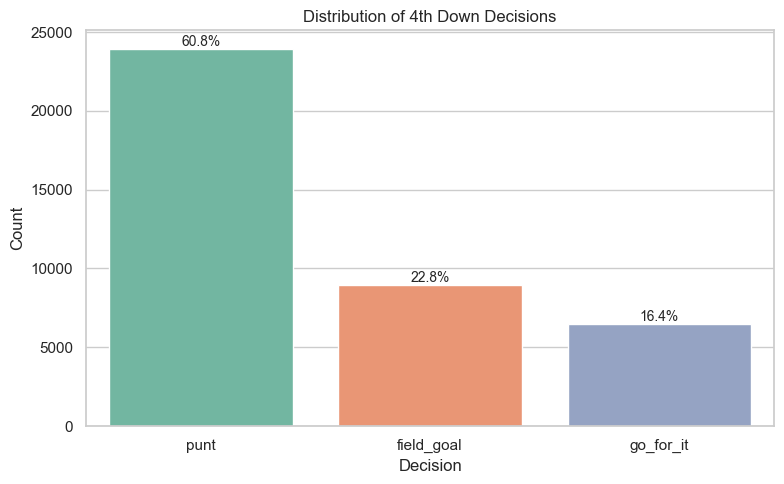

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_32486/2136132897.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


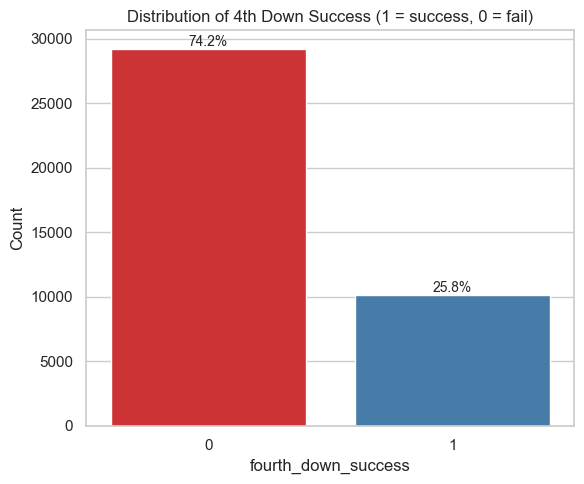

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------------------------------
# 1) Distribution of decision_4th_class
# ---------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=fourth_down_scenarios_v3,
    x="decision_4th_class",
    order=fourth_down_scenarios_v3["decision_4th_class"].value_counts().index,
    palette="Set2"
)

total = len(fourth_down_scenarios_v3)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

ax.set_title("Distribution of 4th Down Decisions")
ax.set_xlabel("Decision")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ---------------------------------
# 2) Distribution of fourth_down_success
# ---------------------------------
plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=fourth_down_scenarios_v3,
    x="fourth_down_success",
    palette="Set1"
)

total_success = len(fourth_down_scenarios_v3)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_success
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

ax.set_title("Distribution of 4th Down Success (1 = success, 0 = fail)")
ax.set_xlabel("fourth_down_success")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [18]:
# subset: only failed 4th-down plays
failed = fourth_down_scenarios_v3[fourth_down_scenarios_v3["fourth_down_success"] == 0]

# counts and percentages within the failed group
failed_counts = failed["decision_4th_class"].value_counts()
failed_pct = failed["decision_4th_class"].value_counts(normalize=True) * 100

print("Failed 4th downs by decision type (counts):")
print(failed_counts)
print("\nFailed 4th downs by decision type (percent of all failures):")
print(failed_pct.round(1))

Failed 4th downs by decision type (counts):
decision_4th_class
punt          23729
go_for_it      4117
field_goal     1350
Name: count, dtype: int64

Failed 4th downs by decision type (percent of all failures):
decision_4th_class
punt          81.3
go_for_it     14.1
field_goal     4.6
Name: proportion, dtype: float64


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_32486/1031960255.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


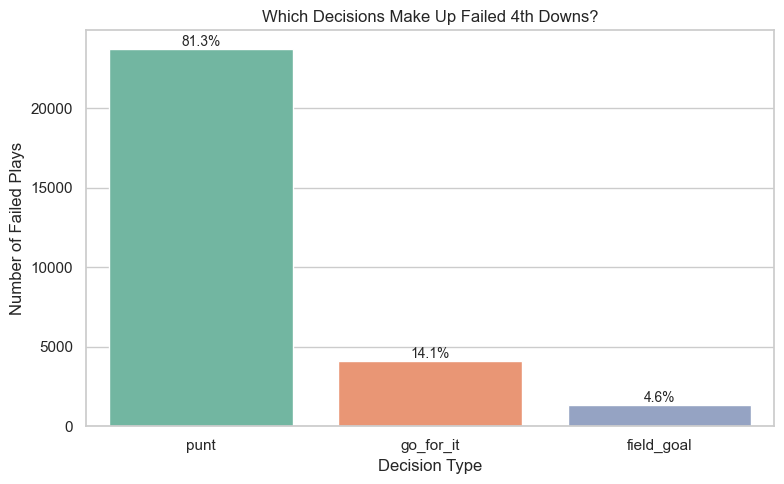

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=failed,
    x="decision_4th_class",
    order=failed["decision_4th_class"].value_counts().index,
    palette="Set2"
)

total_failed = len(failed)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_failed
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

ax.set_title("Which Decisions Make Up Failed 4th Downs?")
ax.set_xlabel("Decision Type")
ax.set_ylabel("Number of Failed Plays")
plt.tight_layout()
plt.show()

In [20]:
go_df = fourth_down_scenarios_v3[
    fourth_down_scenarios_v3["decision_4th_class"] == "go_for_it"
]

go_count = len(go_df)
total = len(fourth_down_scenarios_v3)
print(f"Go-for-it plays: {go_count} ({go_count/total*100:.1f}% of all 4th downs)")

Go-for-it plays: 6450 (16.4% of all 4th downs)


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_32486/2243544248.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


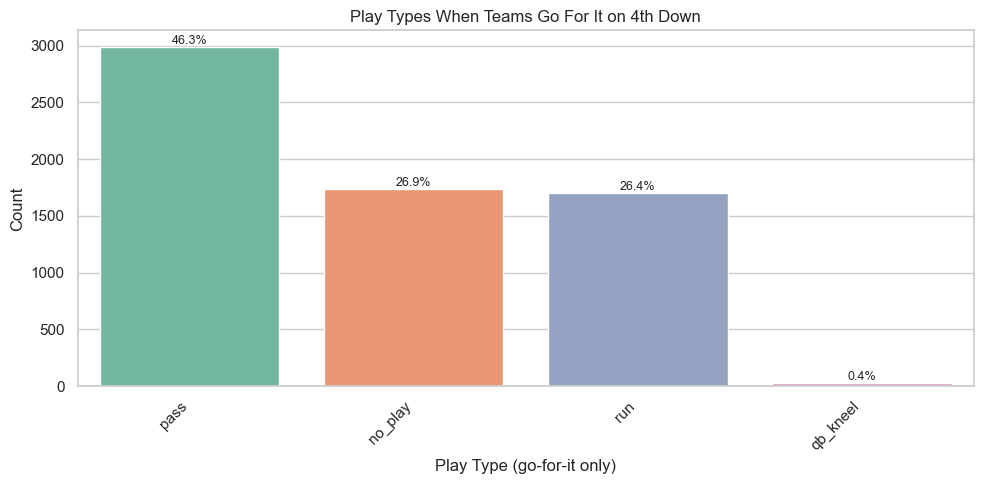

In [21]:
go_df = fourth_down_scenarios_v3[
    fourth_down_scenarios_v3["decision_4th_class"] == "go_for_it"
].copy()

go_df["play_type_clean"] = (
    go_df["play_type"]
    .fillna("")
    .str.strip()
    .str.lower()
)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=go_df,
    x="play_type_clean",
    order=go_df["play_type_clean"].value_counts().index,
    palette="Set2"
)

total_go = len(go_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_go
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9, rotation=0)

ax.set_title("Play Types When Teams Go For It on 4th Down")
ax.set_xlabel("Play Type (go-for-it only)")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

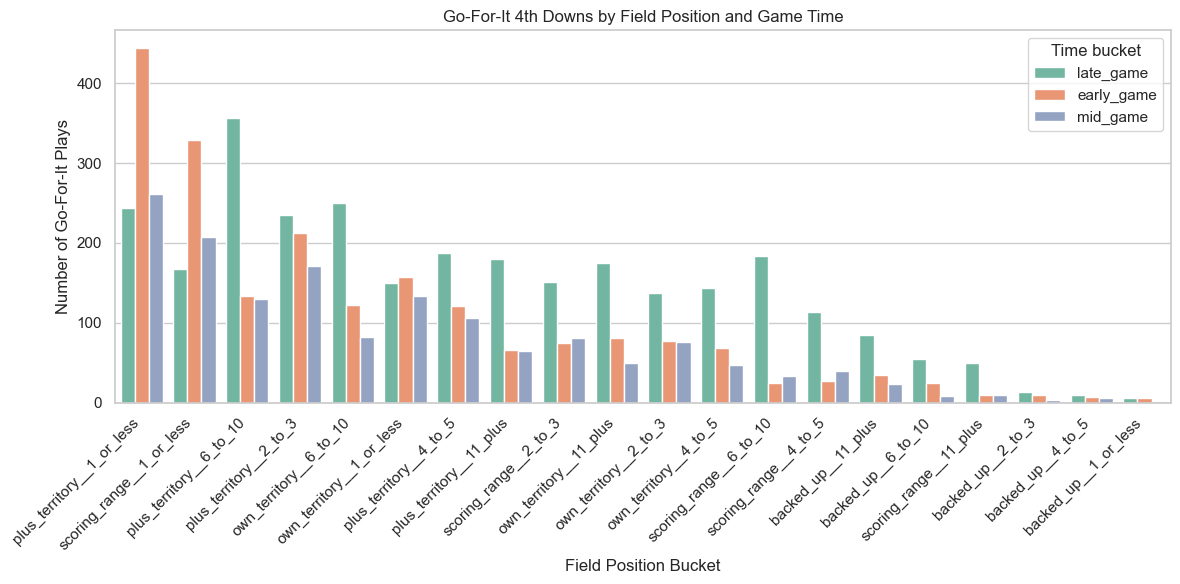

In [22]:
# Let’s visualize how often teams go for it in each field‑position bucket, broken out by time bucket.

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=go_df,
    x="field_position_bucket",
    hue="time_bucket",
    order=go_df["field_position_bucket"].value_counts().index,
    palette="Set2"
)

ax.set_title("Go-For-It 4th Downs by Field Position and Game Time")
ax.set_xlabel("Field Position Bucket")
ax.set_ylabel("Number of Go-For-It Plays")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Time bucket")
plt.tight_layout()
plt.show()

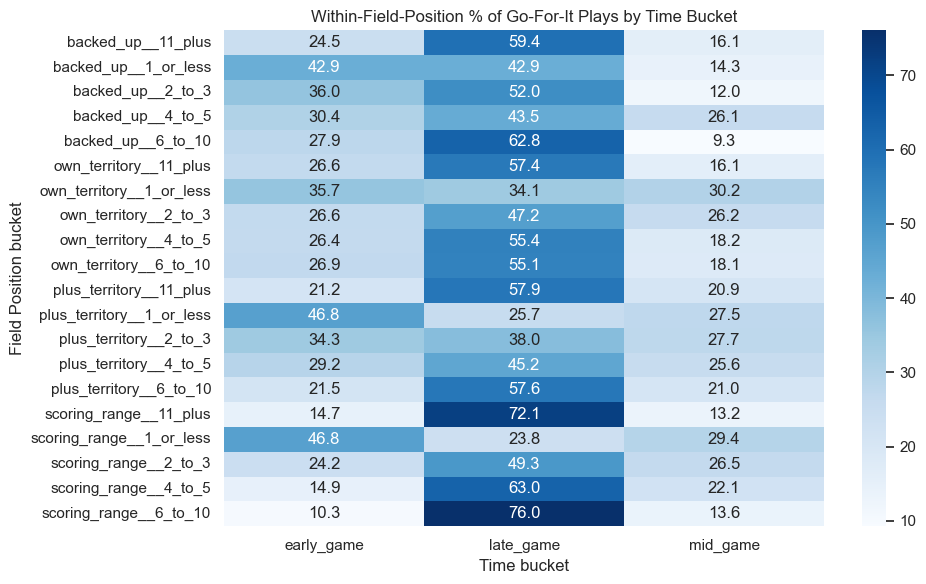

In [23]:
# contingency table
ct = (
    go_df
    .groupby(["field_position_bucket", "time_bucket"])
    .size()
    .unstack(fill_value=0)
)

# convert to row-wise percentages
row_pct = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(row_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Within-Field-Position % of Go-For-It Plays by Time Bucket")
plt.xlabel("Time bucket")
plt.ylabel("Field Position bucket")
plt.tight_layout()
plt.show()

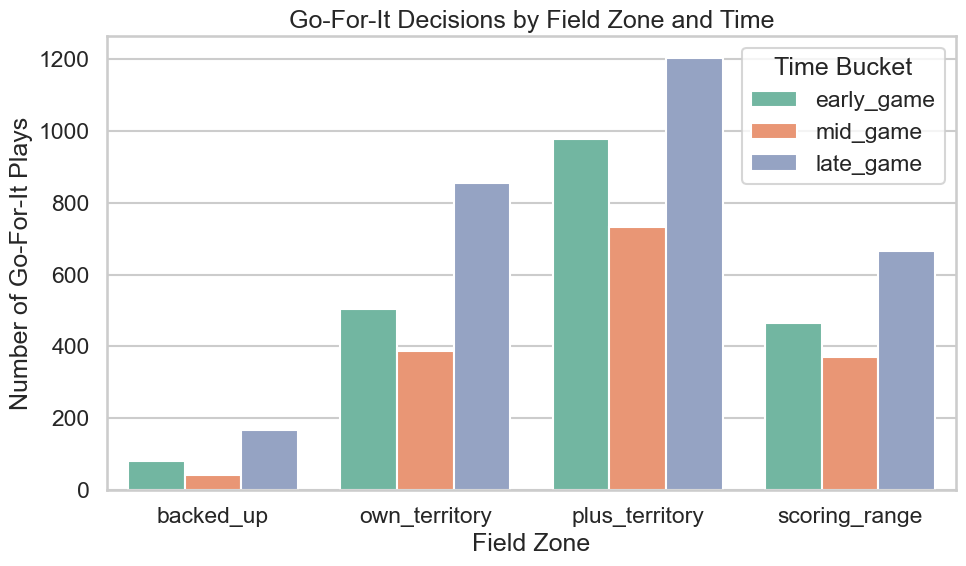

In [24]:

go_df[["field_zone", "distance_bucket"]] = go_df["field_position_bucket"].str.split("__", expand=True)

sns.set(style="whitegrid", context="talk")

field_zone_order = ["backed_up", "own_territory", "plus_territory", "scoring_range"]
time_order = ["early_game", "mid_game", "late_game"]

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=go_df,
    x="field_zone",
    hue="time_bucket",
    order=field_zone_order,
    hue_order=time_order,
    palette="Set2"
)

ax.set_title("Go-For-It Decisions by Field Zone and Time")
ax.set_xlabel("Field Zone")
ax.set_ylabel("Number of Go-For-It Plays")
plt.legend(title="Time Bucket")
plt.tight_layout()
plt.show()

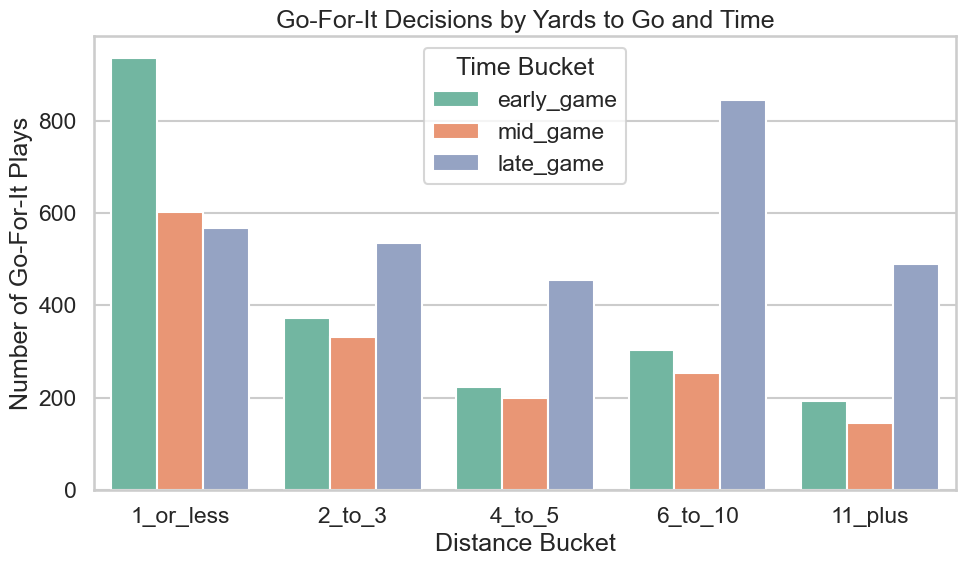

In [25]:
distance_order = ["1_or_less", "2_to_3", "4_to_5", "6_to_10", "11_plus"]

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=go_df,
    x="distance_bucket",
    hue="time_bucket",
    order=distance_order,
    hue_order=time_order,
    palette="Set2"
)

ax.set_title("Go-For-It Decisions by Yards to Go and Time")
ax.set_xlabel("Distance Bucket")
ax.set_ylabel("Number of Go-For-It Plays")
plt.legend(title="Time Bucket")
plt.tight_layout()
plt.show()

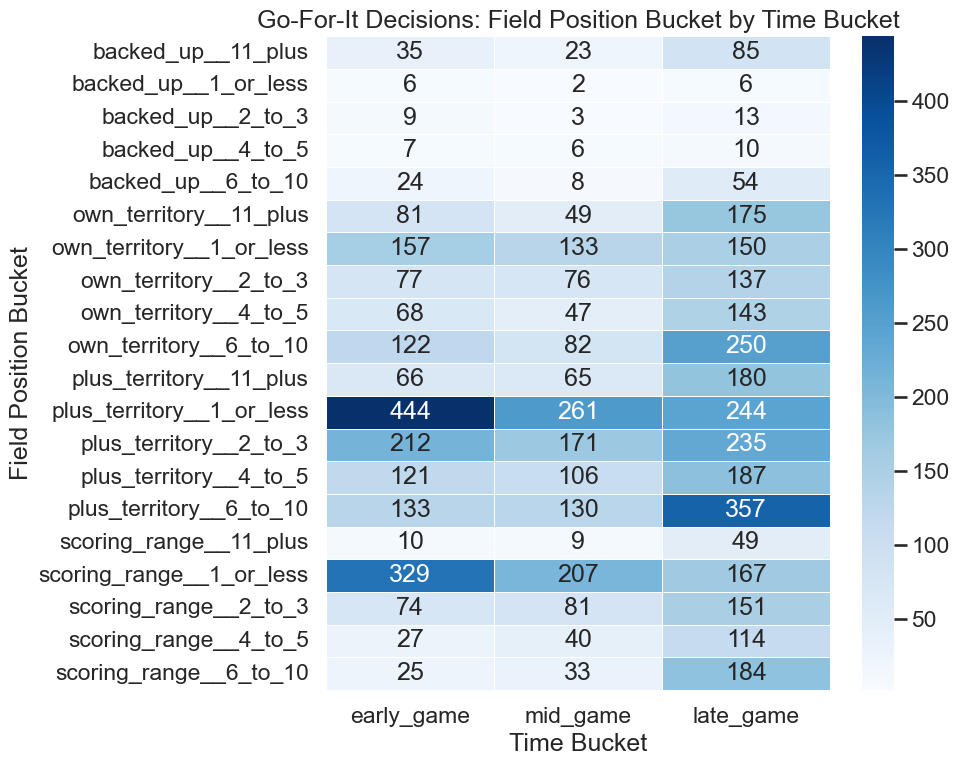

In [26]:
ct = (
    go_df.groupby(["field_position_bucket", "time_bucket"])
    .size()
    .unstack(fill_value=0)
)

ct = ct.reindex(columns=time_order)

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.5)

plt.title("Go-For-It Decisions: Field Position Bucket by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Field Position Bucket")
plt.tight_layout()
plt.show()

<Axes: xlabel='yard_bin', ylabel='count'>

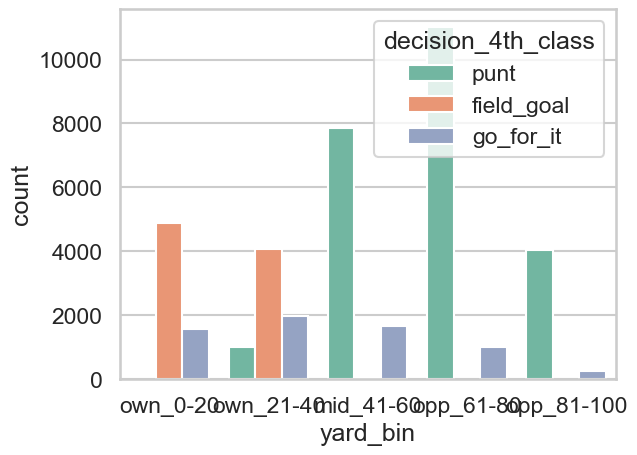

In [27]:
bins = [0, 20, 40, 60, 80, 100]
labels = ["own_0-20", "own_21-40", "mid_41-60", "opp_61-80", "opp_81-100"]
fourth_down_scenarios_v3["yard_bin"] = pd.cut(
    fourth_down_scenarios_v3["yardline_100"], bins=bins, labels=labels, include_lowest=True
)

sns.countplot(
    data=fourth_down_scenarios_v3,
    x="yard_bin",
    hue="decision_4th_class",
    palette="Set2"
)

decision_4th_class
go_for_it    6450
Name: count, dtype: int64

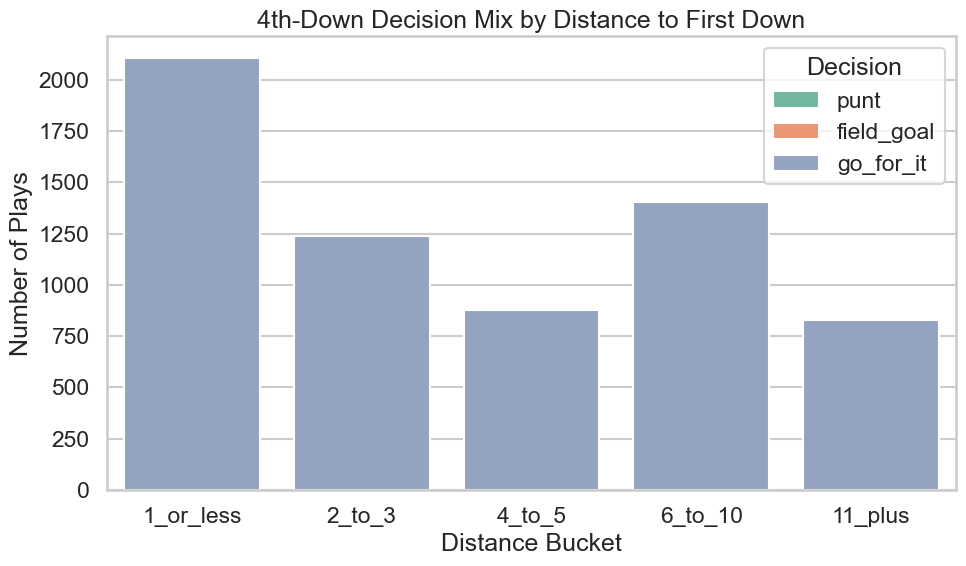

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=go_df,
    x="distance_bucket",
    hue="decision_4th_class",
    order=distance_order,
    hue_order=decision_order,
    palette="Set2"
)
plt.title("4th-Down Decision Mix by Distance to First Down")
plt.xlabel("Distance Bucket")
plt.ylabel("Number of Plays")
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

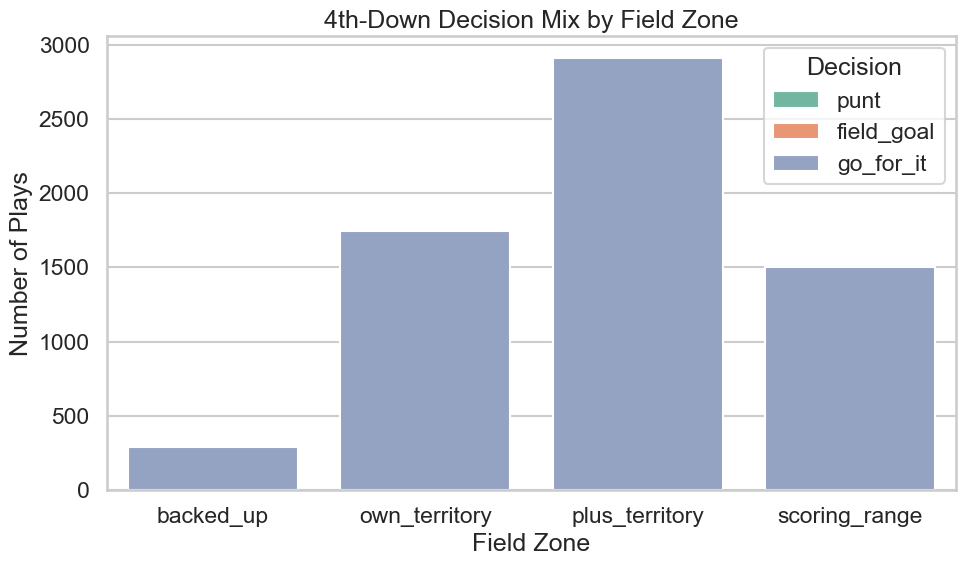

In [33]:
sns.set(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (10, 6)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=go_df,
    x="field_zone",
    hue="decision_4th_class",
    order=field_order,
    hue_order=decision_order,
    palette="Set2"
)
plt.title("4th-Down Decision Mix by Field Zone")
plt.xlabel("Field Zone")
plt.ylabel("Number of Plays")
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

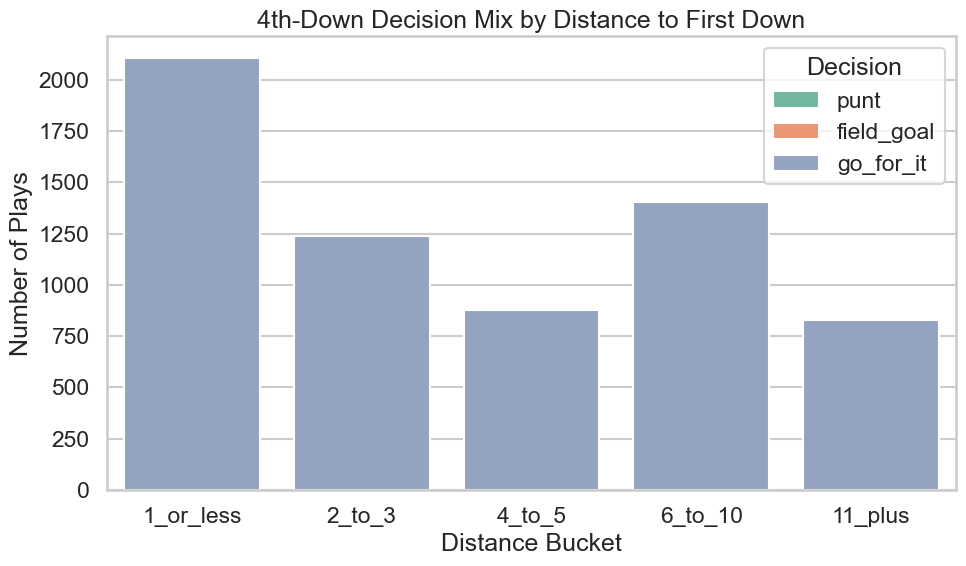

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=go_df,
    x="distance_bucket",
    hue="decision_4th_class",
    order=distance_order,
    hue_order=decision_order,
    palette="Set2"
)
plt.title("4th-Down Decision Mix by Distance to First Down")
plt.xlabel("Distance Bucket")
plt.ylabel("Number of Plays")
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [31]:
go_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6450 entries, 14 to 39335
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   game_id                     6450 non-null   int64  
 1   play_id                     6450 non-null   int64  
 2   home_team                   6450 non-null   object 
 3   away_team                   6450 non-null   object 
 4   qtr                         6450 non-null   int64  
 5   game_seconds_remaining      6450 non-null   float64
 6   posteam_score               6450 non-null   float64
 7   defteam_score               6450 non-null   float64
 8   score_differential          6450 non-null   float64
 9   posteam                     6450 non-null   object 
 10  defteam                     6450 non-null   object 
 11  fourth_down_converted       6450 non-null   float64
 12  fourth_down_failed          6450 non-null   float64
 13  drive                       6450 non